# Galaxy Transition Analysis

**Goal**: Classify galaxies by star formation activity and identify galaxies transitioning from star-forming to quiescent states.

**Approach**:
1. Load galaxy data from ATLAS survey
2. Classify galaxies using BPT diagram (emission line ratios) + D4000 index (stellar age indicator)
3. Analyze how quiescent fraction varies with stellar mass
4. Identify transition-phase galaxies: star-forming galaxies with bulge-dominated structures (Sersic N > 3)

**Key Result**: Star-forming galaxies with high Sersic indices represent galaxies caught in transition—still actively forming stars but developing the structural features of quiescent galaxies.


In [3]:
!pip install seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

path = r"atlas_galaxies.xlsx"  # or full path if needed

df = pd.read_excel(path)
df.shape


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


(145155, 83)

In [4]:
df.head()

,RA,DEC,PLATE,FIBERID,MJD,S2NSAMP,Z,ZDIST,ZDIST_ERR,NMGY_0,...,N2FLUX,N2FLUXERR,HBFLUX,HBFLUXERR,O1FLUX,O1FLUXERR,O2FLUX,O2FLUXERR,O3FLUX,O3FLUXERR
0,146.714209,-1.041282,266,1,51630,35.644699,0.021222,0.020688,0.000445,29.552263,...,294.058075,13.240504,147.918533,15.076868,22.092758,12.022614,-9999.000000,-9999.000000,112.332771,12.699974
1,146.631735,-0.988355,266,6,51630,7.586127,0.052654,0.052031,0.000500,5.937189,...,33.259502,3.634611,47.451176,6.395162,7.674392,3.229252,111.573349,13.896584,40.894810,5.262485
2,147.176447,-0.354030,266,27,51630,11.038011,0.006283,0.006842,0.000442,18.976902,...,6.977154,3.405894,43.585903,7.358572,13.701334,3.803067,-9999.000000,-9999.000000,74.488495,6.113443
3,147.329505,0.028895,266,36,51630,24.391052,0.048086,0.047474,0.000500,21.155905,...,480.081329,8.495414,95.767990,9.061308,17.348866,6.043424,194.422348,16.216930,93.565887,8.352453
4,146.856761,-0.274095,266,72,51630,5.700512,0.021965,0.021350,0.000500,6.950381,...,21.698298,3.045281,59.537476,7.173240,8.554469,3.426046,-9999.000000,-9999.000000,135.053772,6.321954


In [12]:
df = pd.read_excel(path)
df.shape

(145155, 83)

In [ ]:
# Many astronomy catalogs use -9999 as a missing-value flag
SENTINEL = -9999.0

# Replace -9999 with NaN in all numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace(SENTINEL, np.nan)

df[num_cols].isna().mean().sort_values(ascending=False).head(10)

O2FLUXERR    0.151776
O2FLUX       0.151776
HAFLUX       0.005628
N2FLUXERR    0.005628
N2FLUX       0.005628
HAFLUXERR    0.005628
S2FLUXERR    0.004375
S2FLUX       0.004375
O1FLUXERR    0.002542
O1FLUX       0.002542
dtype: float64

In [ ]:
# Flux and error columns of interest
line_cols = {
    "HA": ("HAFLUX", "HAFLUXERR"),
    "HB": ("HBFLUX", "HBFLUXERR"),
    "N2": ("N2FLUX", "N2FLUXERR"),
    "O3": ("O3FLUX", "O3FLUXERR"),
}

for name, (flux_col, err_col) in line_cols.items():
    # Avoid division by zero / NaN
    sn_col = f"{name}_SN"
    df[sn_col] = df[flux_col] / df[err_col]
    
df[["HA_SN", "HB_SN", "N2_SN", "O3_SN"]].describe()

In [14]:
df.head()

,RA,DEC,PLATE,FIBERID,MJD,S2NSAMP,Z,ZDIST,ZDIST_ERR,NMGY_0,...,N2FLUX,N2FLUXERR,HBFLUX,HBFLUXERR,O1FLUX,O1FLUXERR,O2FLUX,O2FLUXERR,O3FLUX,O3FLUXERR
0,146.714209,-1.041282,266,1,51630,35.644699,0.021222,0.020688,0.000445,29.552263,...,294.058075,13.240504,147.918533,15.076868,22.092758,12.022614,NaN,NaN,112.332771,12.699974
1,146.631735,-0.988355,266,6,51630,7.586127,0.052654,0.052031,0.000500,5.937189,...,33.259502,3.634611,47.451176,6.395162,7.674392,3.229252,111.573349,13.896584,40.894810,5.262485
2,147.176447,-0.354030,266,27,51630,11.038011,0.006283,0.006842,0.000442,18.976902,...,6.977154,3.405894,43.585903,7.358572,13.701334,3.803067,NaN,NaN,74.488495,6.113443
3,147.329505,0.028895,266,36,51630,24.391052,0.048086,0.047474,0.000500,21.155905,...,480.081329,8.495414,95.767990,9.061308,17.348866,6.043424,194.422348,16.216930,93.565887,8.352453
4,146.856761,-0.274095,266,72,51630,5.700512,0.021965,0.021350,0.000500,6.950381,...,21.698298,3.045281,59.537476,7.173240,8.554469,3.426046,NaN,NaN,135.053772,6.321954


In [16]:
df.head()

,RA,DEC,PLATE,FIBERID,MJD,S2NSAMP,Z,ZDIST,ZDIST_ERR,NMGY_0,...,O2FLUXERR,O3FLUX,O3FLUXERR,HA_SN,HB_SN,N2_SN,O3_SN,logN2_HA,logO3_HB,GAL_CLASS
0,146.714209,-1.041282,266,1,51630,35.644699,0.021222,0.020688,0.000445,29.552263,...,NaN,112.332771,12.699974,42.180515,9.810959,22.208979,8.845118,-0.298391,-0.119516,composite
1,146.631735,-0.988355,266,6,51630,7.586127,0.052654,0.052031,0.000500,5.937189,...,13.896584,40.894810,5.262485,37.491829,7.419856,9.150774,7.771008,-0.677394,-0.064579,star-forming
2,147.176447,-0.354030,266,27,51630,11.038011,0.006283,0.006842,0.000442,18.976902,...,NaN,74.488495,6.113443,34.295399,5.923147,2.048553,12.184377,NaN,NaN,ambiguous
3,147.329505,0.028895,266,36,51630,24.391052,0.048086,0.047474,0.000500,21.155905,...,16.216930,93.565887,8.352453,69.519343,10.568893,56.510647,11.202204,-0.132445,-0.010103,composite
4,146.856761,-0.274095,266,72,51630,5.700512,0.021965,0.021350,0.000500,6.950381,...,NaN,135.053772,6.321954,53.898175,8.299942,7.125219,21.362662,-0.969248,0.355716,star-forming


In [17]:

def sn(flux, err):
    err = err.replace(0, np.nan)
    return flux / err

# S/N
df["HA_SN"] = sn(df["HAFLUX"], df["HAFLUXERR"])
df["HB_SN"] = sn(df["HBFLUX"], df["HBFLUXERR"])
df["N2_SN"] = sn(df["N2FLUX"], df["N2FLUXERR"])
df["O3_SN"] = sn(df["O3FLUX"], df["O3FLUXERR"])

SN_DET = 3.0
SN_NONDET = 2.0   # softer "non-detection" threshold for fallbacks

ha_det = df["HA_SN"] >= SN_DET
hb_det = df["HB_SN"] >= SN_DET
n2_det = df["N2_SN"] >= SN_DET
o3_det = df["O3_SN"] >= SN_DET

# BPT-valid subset
bpt_ok = (
    ha_det & hb_det & n2_det & o3_det &
    (df["HAFLUX"] > 0) & (df["HBFLUX"] > 0) &
    (df["N2FLUX"] > 0) & (df["O3FLUX"] > 0)
)

x = np.full(len(df), np.nan)  # log([NII]/Halpha)
y = np.full(len(df), np.nan)  # log([OIII]/Hbeta)
x[bpt_ok] = np.log10(df.loc[bpt_ok, "N2FLUX"] / df.loc[bpt_ok, "HAFLUX"])
y[bpt_ok] = np.log10(df.loc[bpt_ok, "O3FLUX"] / df.loc[bpt_ok, "HBFLUX"])

kauff = 0.61 / (x - 0.05) + 1.30
kewley = 0.61 / (x - 0.47) + 1.19

sf_bpt   = bpt_ok & (y < kauff)
comp_bpt = bpt_ok & (y >= kauff) & (y < kewley)
agn_bpt  = bpt_ok & (y >= kewley)

# D4000 cuts (no buffer, classify more)
D4000_OLD = 1.6
old = df["D4000"] >= D4000_OLD
young = ~old

# Initialize
df["GAL_CLASS"] = "ambiguous"

# 1) Use BPT when possible
df.loc[sf_bpt, "GAL_CLASS"]   = "star-forming"
df.loc[comp_bpt, "GAL_CLASS"] = "composite"
df.loc[agn_bpt, "GAL_CLASS"]  = "agn"

# 2) Fallback: if BPT not available, use D4000 + Hα
no_bpt = ~bpt_ok

# Star-forming fallback: Hα detected + not old stellar pop dominated
df.loc[no_bpt & young & ha_det, "GAL_CLASS"] = "star-forming"

# Quiescent fallback: old + Hα clearly not detected (even if other lines are weird)
df.loc[no_bpt & old & (df["HA_SN"] < SN_NONDET), "GAL_CLASS"] = "quiescent"

df["GAL_CLASS"].value_counts()

GAL_CLASS
star-forming    71075
ambiguous       50929
composite        8934
quiescent        8439
agn              5778
Name: count, dtype: int64

In [35]:
clean = df[df["GAL_CLASS"].isin(["star-forming","quiescent"])].copy()

In [36]:

clean["logMASS"] = np.log10(clean["MASS"])

In [37]:
clean["logMASS"].describe()

count    79514.000000
mean         9.272312
std          0.644276
min          4.847972
25%          8.909617
50%          9.326738
75%          9.701397
max         12.517896
Name: logMASS, dtype: float64

In [38]:
mass_bins = np.arange(7.5, 12.5, 0.25)

clean["mass_bin"] = pd.cut(clean["logMASS"], bins=mass_bins)

In [39]:
mass_stats = clean.groupby("mass_bin")["GAL_CLASS"].value_counts().unstack()

mass_stats["total"] = mass_stats.sum(axis=1)
mass_stats["quiescent_fraction"] = mass_stats["quiescent"] / mass_stats["total"]

mass_stats

C:\Users\reem2\AppData\Local\Temp\ipykernel_15236\1752227427.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mass_stats = clean.groupby("mass_bin")["GAL_CLASS"].value_counts().unstack()


GAL_CLASS,quiescent,star-forming,total,quiescent_fraction
mass_bin,,,,
"(7.5, 7.75]",6,743,749,0.008011
"(7.75, 8.0]",12,1225,1237,0.009701
"(8.0, 8.25]",15,2100,2115,0.007092
"(8.25, 8.5]",16,3532,3548,0.004510
"(8.5, 8.75]",78,5739,5817,0.013409
"(8.75, 9.0]",203,8691,8894,0.022824
"(9.0, 9.25]",511,11492,12003,0.042573
"(9.25, 9.5]",1116,12808,13924,0.080149
"(9.5, 9.75]",1816,10592,12408,0.146357


c:\Users\reem2\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


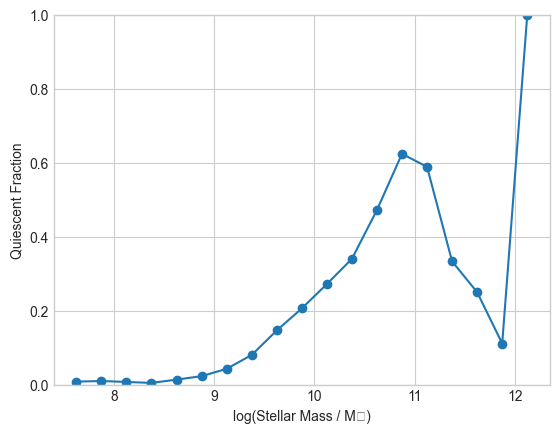

In [40]:

bin_centers = mass_stats.index.map(lambda x: x.mid)

plt.plot(bin_centers, mass_stats["quiescent_fraction"], marker="o")
plt.xlabel("log(Stellar Mass / M☉)")
plt.ylabel("Quiescent Fraction")
plt.ylim(0,1)
plt.show()

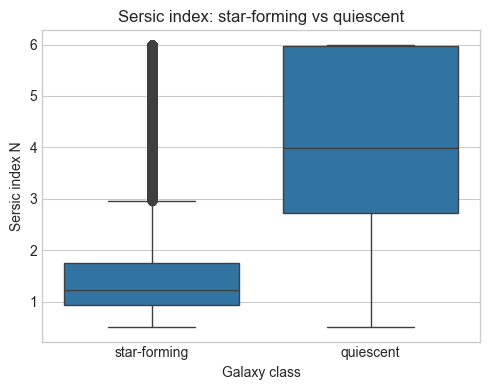

In [56]:
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=clean.dropna(subset=["SERSIC_N"]),
    x="GAL_CLASS",
    y="SERSIC_N",
)
plt.xlabel("Galaxy class")
plt.ylabel("Sersic index N")
plt.title("Sersic index: star-forming vs quiescent")
plt.tight_layout()
plt.show()

Star-forming with SERSIC_N > 3: 6439 galaxies


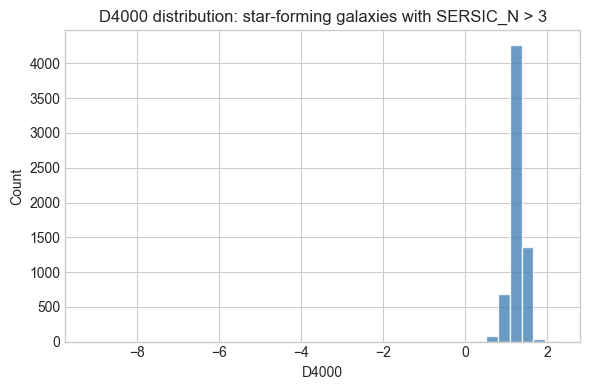

In [59]:
# Star-forming galaxies with SERSIC_N > 3: D4000 distribution
sf_bulgy = df[(df["GAL_CLASS"] == "star-forming") & (df["SERSIC_N"] > 3)].copy()
sf_bulgy = sf_bulgy.dropna(subset=["D4000"])

print(f"Star-forming with SERSIC_N > 3: {len(sf_bulgy)} galaxies")

plt.figure(figsize=(6, 4))
plt.hist(sf_bulgy["D4000"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
plt.xlabel("D4000")
plt.ylabel("Count")
plt.title("D4000 distribution: star-forming galaxies with SERSIC_N > 3")
plt.tight_layout()
plt.show()

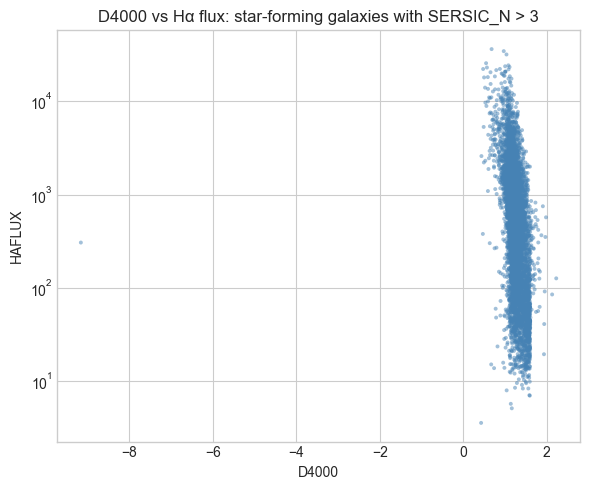

In [60]:
# Star-forming with SERSIC_N > 3: D4000 vs HAFLUX
sf_bulgy = df[(df["GAL_CLASS"] == "star-forming") & (df["SERSIC_N"] > 3)].copy()
sf_bulgy = sf_bulgy.dropna(subset=["D4000", "HAFLUX"])

plt.figure(figsize=(6, 5))
plt.scatter(sf_bulgy["D4000"], sf_bulgy["HAFLUX"], s=8, alpha=0.5, c="steelblue", edgecolors="none")
plt.xlabel("D4000")
plt.ylabel("HAFLUX")
plt.title("D4000 vs Hα flux: star-forming galaxies with SERSIC_N > 3")
plt.yscale("log")   # Hα flux often spans many orders of magnitude
plt.tight_layout()
plt.show()

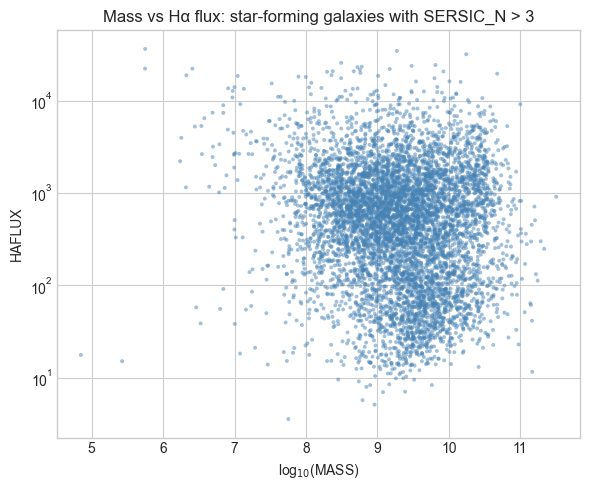

In [63]:
# Star-forming with SERSIC_N > 3: mass vs HAFLUX
sf_bulgy = df[(df["GAL_CLASS"] == "star-forming") & (df["SERSIC_N"] > 3)].copy()
sf_bulgy = sf_bulgy.dropna(subset=["MASS", "HAFLUX"])
sf_bulgy["logMASS"] = np.log10(sf_bulgy["MASS"])

plt.figure(figsize=(6, 5))
plt.scatter(sf_bulgy["logMASS"], sf_bulgy["HAFLUX"], s=8, alpha=0.5, c="steelblue", edgecolors="none")
plt.xlabel(r"log$_{10}$(MASS)")
plt.ylabel("HAFLUX")
plt.title("Mass vs Hα flux: star-forming galaxies with SERSIC_N > 3")
plt.yscale("log")
plt.tight_layout()
plt.show()